# **Import library:**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("D:\project\python\my library")
import style_plot as sp

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

---

# **Read data:**

In [2]:
df = pd.read_csv('customer_segmentation.csv')

In [3]:
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


---

# **Check data:**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>

RangeIndex: 2240 entries, 0 to 2239

Data columns (total 29 columns):

 #   Column               Non-Null Count  Dtype  

---  ------               --------------  -----  

 0   ID                   2240 non-null   int64  

 1   Year_Birth           2240 non-null   int64  

 2   Education            2240 non-null   object 

 3   Marital_Status       2240 non-null   object 

 4   Income               2216 non-null   float64

 5   Kidhome              2240 non-null   int64  

 6   Teenhome             2240 non-null   int64  

 7   Dt_Customer          2240 non-null   object 

 8   Recency              2240 non-null   int64  

 9   MntWines             2240 non-null   int64  

 10  MntFruits            2240 non-null   int64  

 11  MntMeatProducts      2240 non-null   int64  

 12  MntFishProducts      2240 non-null   int64  

 13  MntSweetProducts     2240 non-null   int64  

 14  MntGoldProds         2240 non-null   int64  

 15  NumDealsPurchases 

In [5]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [6]:
print(f'Missing values: {df.isna().sum().sum()}')
print(f'Duplicated values: {df.duplicated().sum().sum()}')

Missing values: 24

Duplicated values: 0


---

# **Data cleaning:**

In [7]:
df[df['Income'].isna()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,...,6,0,0,0,0,0,0,3,11,0


In [8]:
imputer = SimpleImputer(strategy='median')

df[['Income']] = imputer.fit_transform(df[['Income']])

In [9]:
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [10]:
print(f'Missing values: {df.isna().sum().sum()}')
print(f'Duplicated values: {df.duplicated().sum().sum()}')

Missing values: 0

Duplicated values: 0


---

# **Edit data:**

In [11]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [12]:
l= df['Dt_Customer'].str.split('-')
df['Dt_day'] = [x[0] for x in l]
df['Dt_month'] = [x[1] for x in l]
df['Dt_year'] = [x[2] for x in l]
df.drop(columns=['Dt_Customer','ID'])

df['Dt_day'] = df['Dt_day'].astype(int)
df['Dt_month'] = df['Dt_month'].astype(int)
df['Dt_year'] = df['Dt_year'].astype(int)

new_order = ['Year_Birth','Education','Marital_Status','Income','Kidhome','Teenhome','Dt_day','Dt_month','Dt_year','Recency','MntWines',
             'MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds','NumDealsPurchases','NumWebPurchases',
             'NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth','AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4',
             'AcceptedCmp5','Complain','Z_CostContact','Z_Revenue','Response']

df = df[new_order]

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>

RangeIndex: 2240 entries, 0 to 2239

Data columns (total 30 columns):

 #   Column               Non-Null Count  Dtype  

---  ------               --------------  -----  

 0   Year_Birth           2240 non-null   int64  

 1   Education            2240 non-null   object 

 2   Marital_Status       2240 non-null   object 

 3   Income               2240 non-null   float64

 4   Kidhome              2240 non-null   int64  

 5   Teenhome             2240 non-null   int64  

 6   Dt_day               2240 non-null   int32  

 7   Dt_month             2240 non-null   int32  

 8   Dt_year              2240 non-null   int32  

 9   Recency              2240 non-null   int64  

 10  MntWines             2240 non-null   int64  

 11  MntFruits            2240 non-null   int64  

 12  MntMeatProducts      2240 non-null   int64  

 13  MntFishProducts      2240 non-null   int64  

 14  MntSweetProducts     2240 non-null   int64  

 15  MntGoldProds      

In [14]:
df.head(5)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_day,Dt_month,Dt_year,Recency,...,NumWebVisitsMonth,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Complain,Z_CostContact,Z_Revenue,Response
0,1957,Graduation,Single,58138.0,0,0,4,9,2012,58,...,7,0,0,0,0,0,0,3,11,1
1,1954,Graduation,Single,46344.0,1,1,8,3,2014,38,...,5,0,0,0,0,0,0,3,11,0
2,1965,Graduation,Together,71613.0,0,0,21,8,2013,26,...,4,0,0,0,0,0,0,3,11,0
3,1984,Graduation,Together,26646.0,1,0,10,2,2014,26,...,6,0,0,0,0,0,0,3,11,0
4,1981,PhD,Married,58293.0,1,0,19,1,2014,94,...,5,0,0,0,0,0,0,3,11,0


---

# **Analyses data:**

In [15]:
sp.help()





    Function                Describe                                                                            Parameters

    style_grid()            Change the background style of the graph of the seaborn library                     background_style, line_transparant, type_line

    

    bar_style()             This function makes the bar with the highest value one color                        variable, max_color, min_color

                            and the rest of the bars another color.

    

    bar_values()            It is a function that places the value of the bar on its subordinate bar            value



    barh_values()           Same function as "bar_values()" but with 'barh'                                     value_h



    multe_bar()             It includes some of the above functions but its purpose is to make                  raw, column, graph_num, value, wid, rot, tit, max_color, min_color

                            more than one bar chart

    

    m

In [16]:
sp.style_grid('darkgrid','0.6',':')

## *1. Year_Birth*

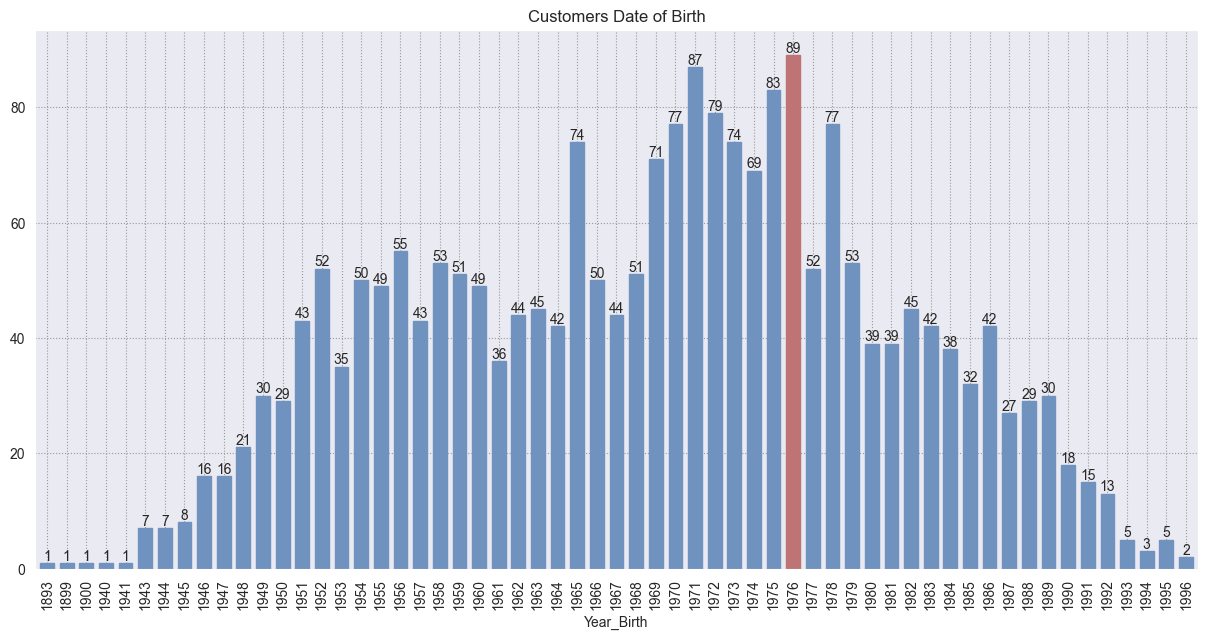

In [17]:
x = df['Year_Birth'].value_counts()

plt.figure(figsize=(15,7))
x = x.sort_index()
col = sp.bar_style(x, '#BE7475', '#7092BE')
graph = x.plot(kind='bar', color=col, edgecolor=col, width=0.7, title='Customers Date of Birth')
sp.bar_values(graph)

## *2. Education*

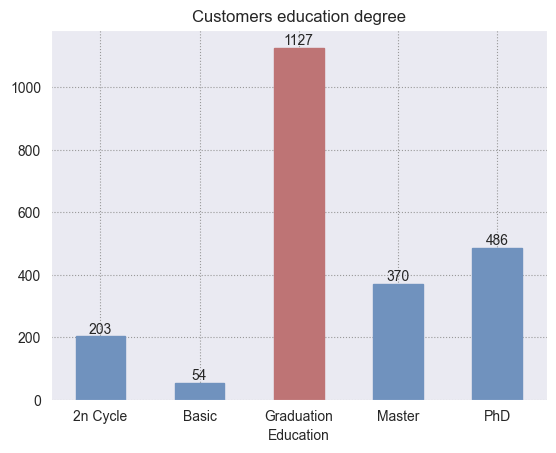

In [18]:
x = df['Education'].value_counts()

x = x.sort_index()
col = sp.bar_style(x, '#BE7475', '#7092BE')
graph = x.plot(kind='bar', color=col, edgecolor=col, title='Customers education degree')
plt.xticks(rotation=0)
sp.bar_values(graph)

1. **Basic**: This typically refers to primary and secondary education, which provides foundational skills in literacy, numeracy, and basic knowledge in various subjects. It usually encompasses education from early childhood through high school.

2. **2n Cycle**: This term often refers to the second stage of higher education, which can vary by country. In some contexts, it means a level of education that follows basic education and is often equivalent to undergraduate studies.

3. **Graduation**: This generally refers to the completion of a degree program, often at the undergraduate level (e.g., a bachelor's degree). Graduation signifies that a student has met the required academic criteria and is awarded a degree.

4. **Master**: This is a graduate-level degree that typically follows the completion of a bachelor's degree. It usually requires one to two years of study and involves advanced coursework and often a thesis or capstone project.

5. **PhD (Doctor of Philosophy)**: This is the highest level of academic degree. It typically requires several years of study beyond a master’s degree, including original research and the completion of a dissertation. A PhD signifies a high level of expertise in a specific field and is often required for academic and research positions.

## *3. Marital_Status*

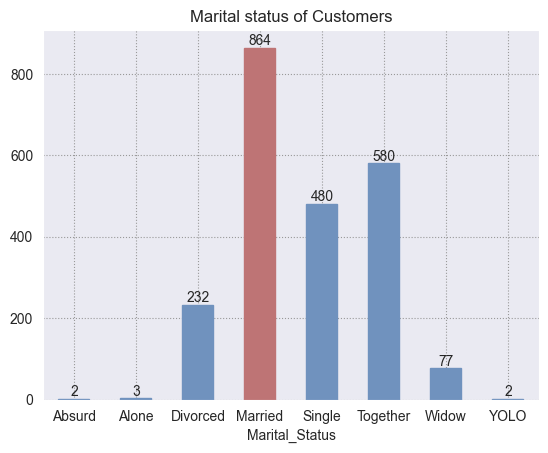

In [19]:
x = df['Marital_Status'].value_counts()

x = x.sort_index()
col = sp.bar_style(x, '#BE7475', '#7092BE')
graph = x.plot(kind='bar', color=col, edgecolor=col, title='Marital status of Customers')
plt.xticks(rotation=0)
sp.bar_values(graph)

## *4. Income*

,Income
count,2240.000000
mean,52237.975446
std,25037.955891
min,1730.000000
25%,35538.750000
50%,51381.500000
75%,68289.750000
max,666666.000000


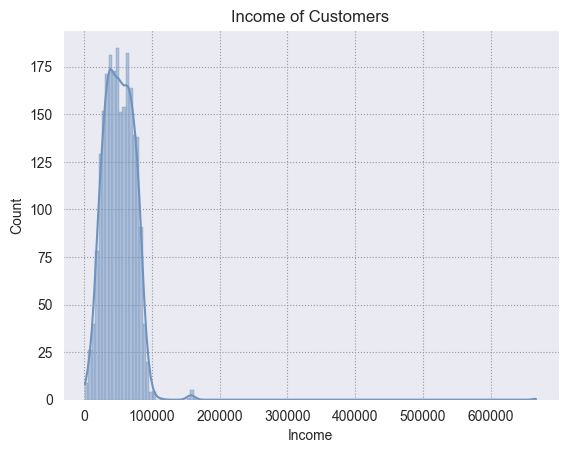

In [20]:
x = df['Income']

col = '#7092BE'
sns.histplot(x, kde=True, color=col, edgecolor=col)
plt.title('Income of Customers')
pd.DataFrame(x.describe())

In [21]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df = df[(df['Income'] >= lower_bound) & (df['Income'] <= upper_bound)]

,Income
count,2232.000000
mean,51630.926971
std,20601.679542
min,1730.000000
25%,35434.750000
50%,51381.500000
75%,68118.000000
max,113734.000000


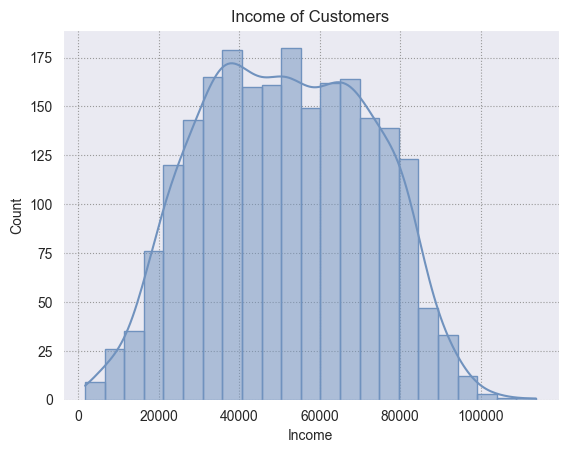

In [22]:
x = df['Income']

col = '#7092BE'
sns.histplot(x, kde=True, color=col, edgecolor=col)
plt.title('Income of Customers')
pd.DataFrame(x.describe())

## *5. Children*

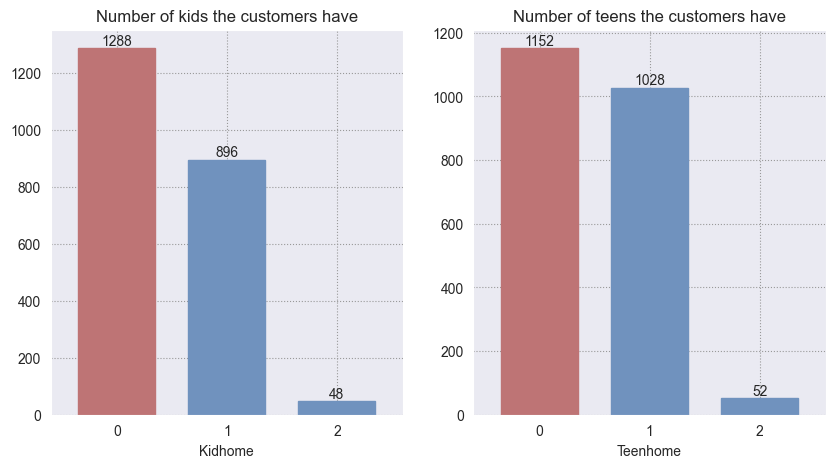

In [23]:
kid = df['Kidhome'].value_counts()
teen = df['Teenhome'].value_counts()

plt.figure(figsize=(10,5))
max_color = '#BE7475'
min_color = '#7092BE'

sp.multe_bar(1,2,1,kid,0.7,0,'Number of kids the customers have', max_color, min_color)
sp.multe_bar(1,2,2,teen,0.7,0,'Number of teens the customers have', max_color, min_color)

## *6. Date_Customer*

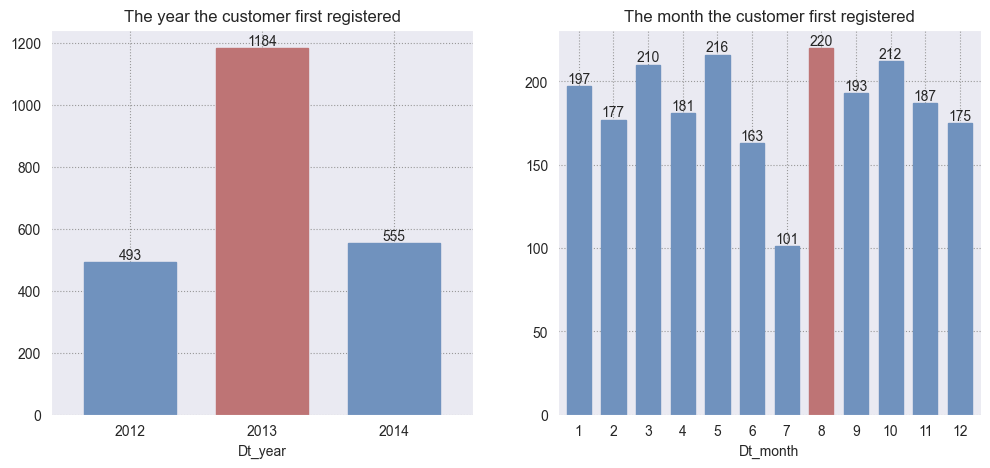

In [24]:
year = df['Dt_year'].value_counts()
month = df['Dt_month'].value_counts()

plt.figure(figsize=(12,5))
max_color = '#BE7475'
min_color = '#7092BE'

sp.multe_bar(1,2,1,year,0.7,0,'The year the customer first registered', max_color, min_color)
sp.multe_bar(1,2,2,month,0.7,0,'The month the customer first registered', max_color, min_color)

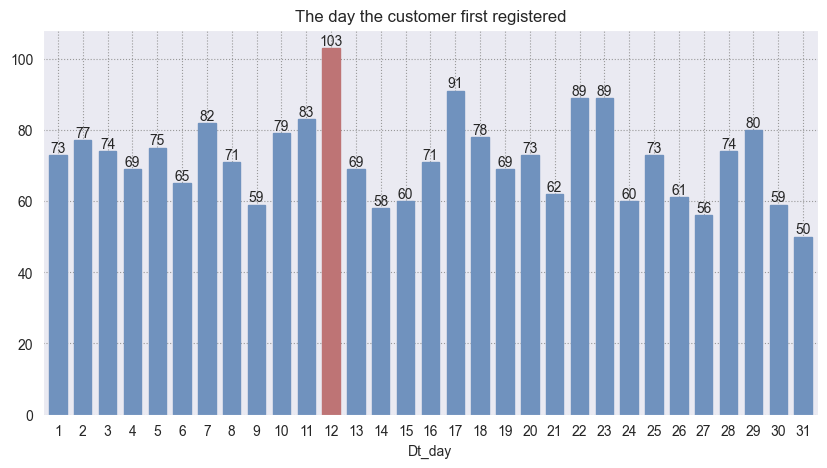

In [25]:
day = df['Dt_day'].value_counts()

plt.figure(figsize=(10,5))

day = day.sort_index()
col = sp.bar_style(day, '#BE7475', '#7092BE')
graph_day = day.plot(kind='bar', color=col, edgecolor=col, width=0.7, title='The day the customer first registered')
plt.xticks(rotation=0)
sp.bar_values(graph_day)

## *7. Recency*

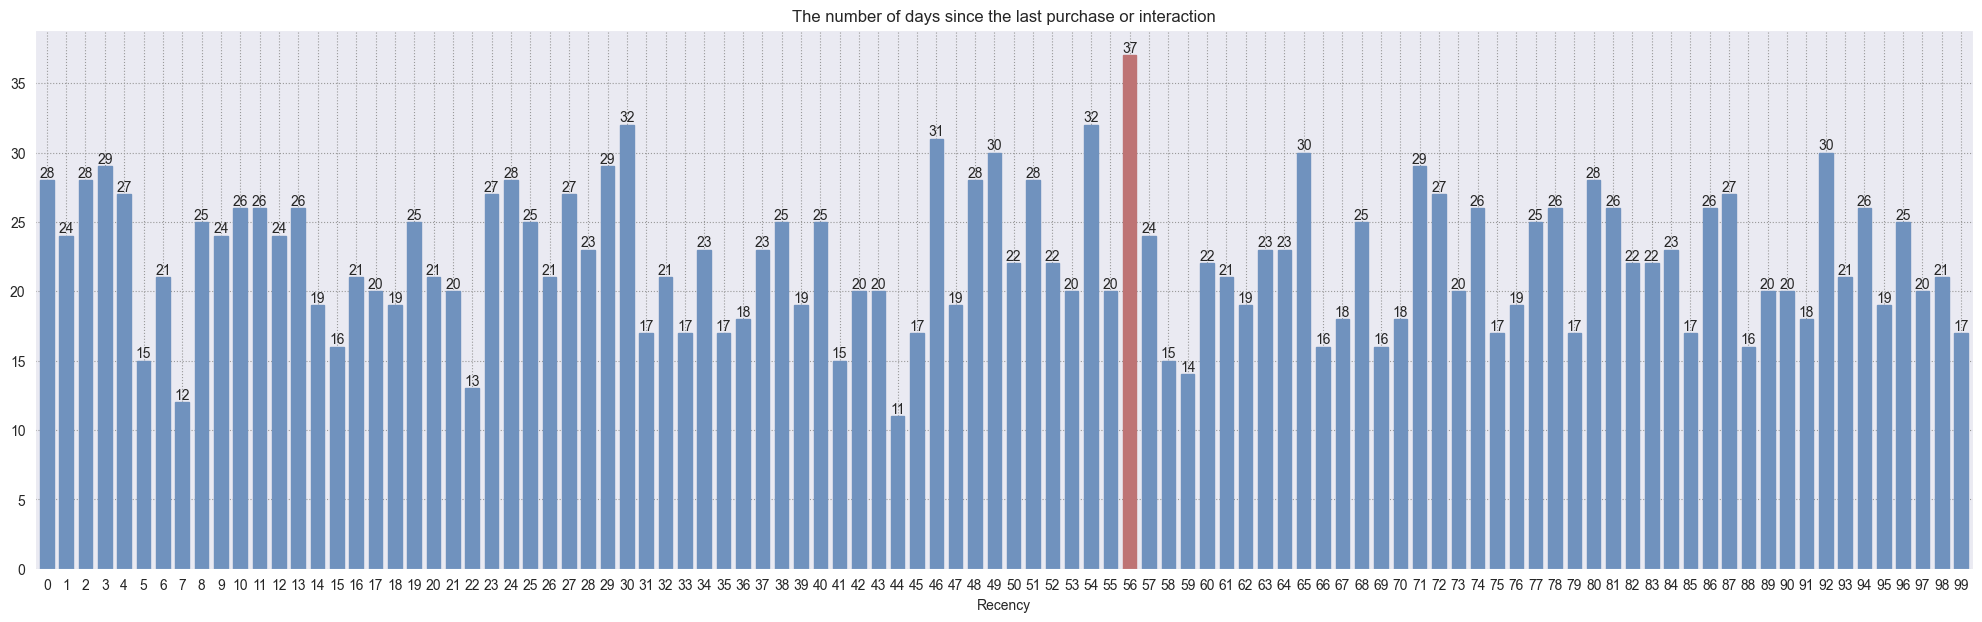

In [26]:
x = df['Recency'].value_counts()

plt.figure(figsize=(25,7))

x = x.sort_index()
col = sp.bar_style(x, '#BE7475', '#7092BE')
graph = x.plot(kind='bar', color=col, edgecolor=col, width=0.7, title='The number of days since the last purchase or interaction')
plt.xticks(rotation=0)
sp.bar_values(graph)

## *8. products*

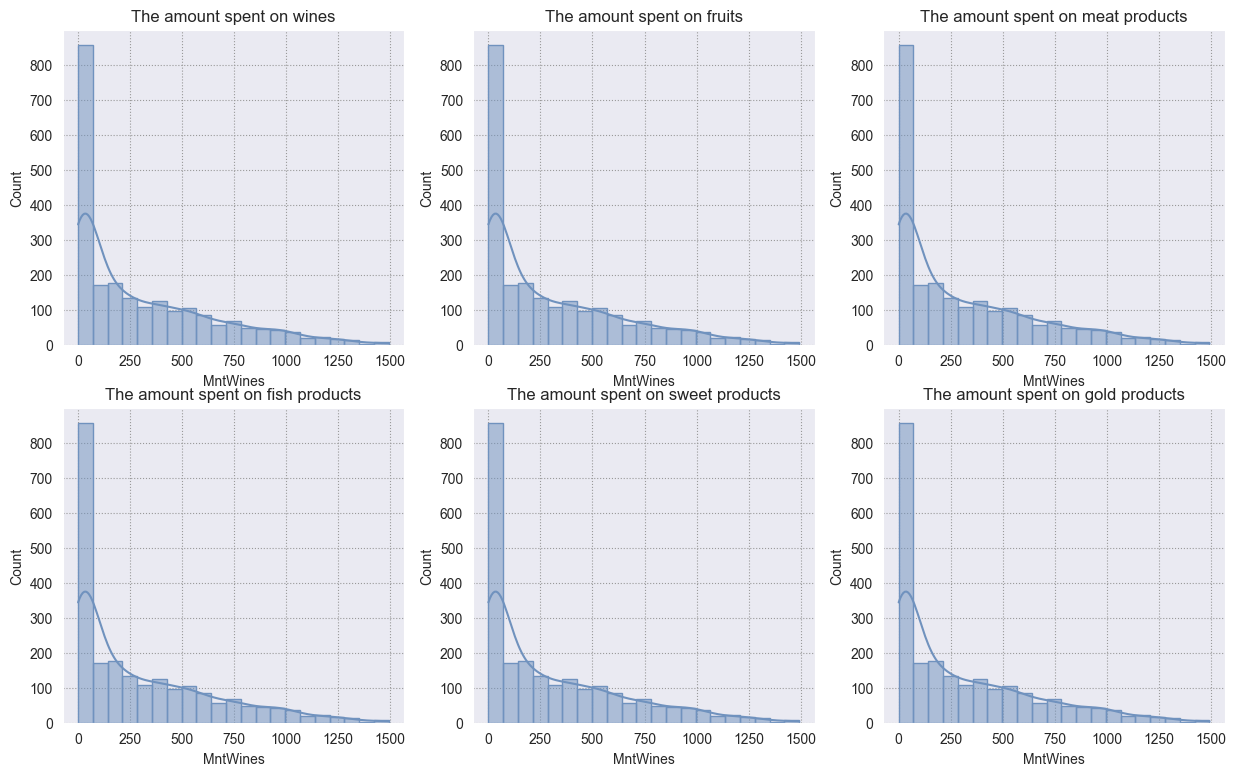

In [27]:
win = df['MntWines']
fruit = df['MntFruits']
meat = df['MntMeatProducts']
fish = df['MntFishProducts']
sweet = df['MntSweetProducts']
gold = df['MntGoldProds']

plt.figure(figsize=(15,9))
col = '#7092BE'

sp.multe_hist(2,3,1, win, True, 'The amount spent on wines', col, col)
sp.multe_hist(2,3,2, win, True, 'The amount spent on fruits', col, col)
sp.multe_hist(2,3,3, win, True, 'The amount spent on meat products', col, col)
sp.multe_hist(2,3,4, win, True, 'The amount spent on fish products', col, col)
sp.multe_hist(2,3,5, win, True, 'The amount spent on sweet products', col, col)
sp.multe_hist(2,3,6, win, True, 'The amount spent on gold products', col, col)

## *9. purchases*

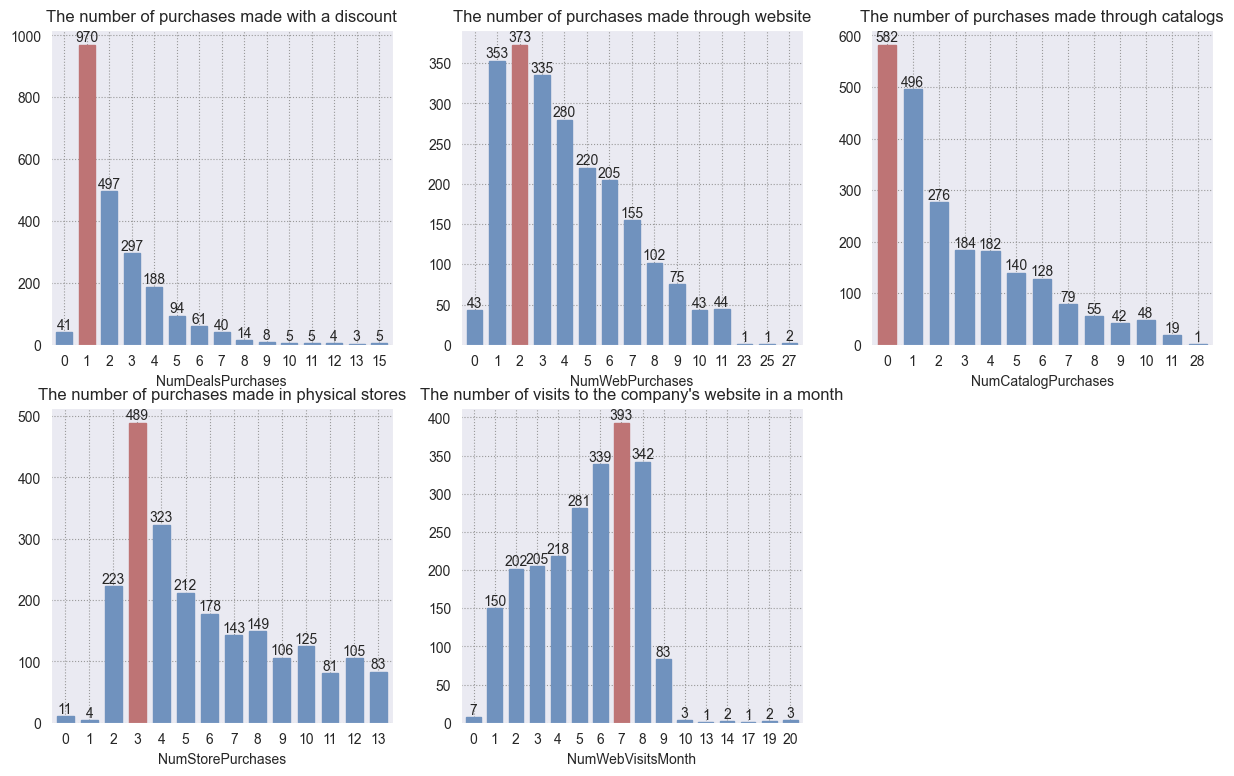

In [28]:
deals = df['NumDealsPurchases'].value_counts()
web = df['NumWebPurchases'].value_counts()
catalog = df['NumCatalogPurchases'].value_counts()
tore = df['NumStorePurchases'].value_counts()
web_visit = df['NumWebVisitsMonth'].value_counts()

plt.figure(figsize=(15,9))
max_color = '#BE7475'
min_color = '#7092BE'

sp.multe_bar(2,3,1, deals, 0.7, 0, 'The number of purchases made with a discount', max_color, min_color)
sp.multe_bar(2,3,2, web, 0.7, 0, 'The number of purchases made through website', max_color, min_color)
sp.multe_bar(2,3,3, catalog, 0.7, 0, 'The number of purchases made through catalogs', max_color, min_color)
sp.multe_bar(2,3,4, tore, 0.7, 0, 'The number of purchases made in physical stores', max_color, min_color)
sp.multe_bar(2,3,5, web_visit, 0.7, 0, "The number of visits to the company's website in a month", max_color, min_color)

## *10. Accepted*

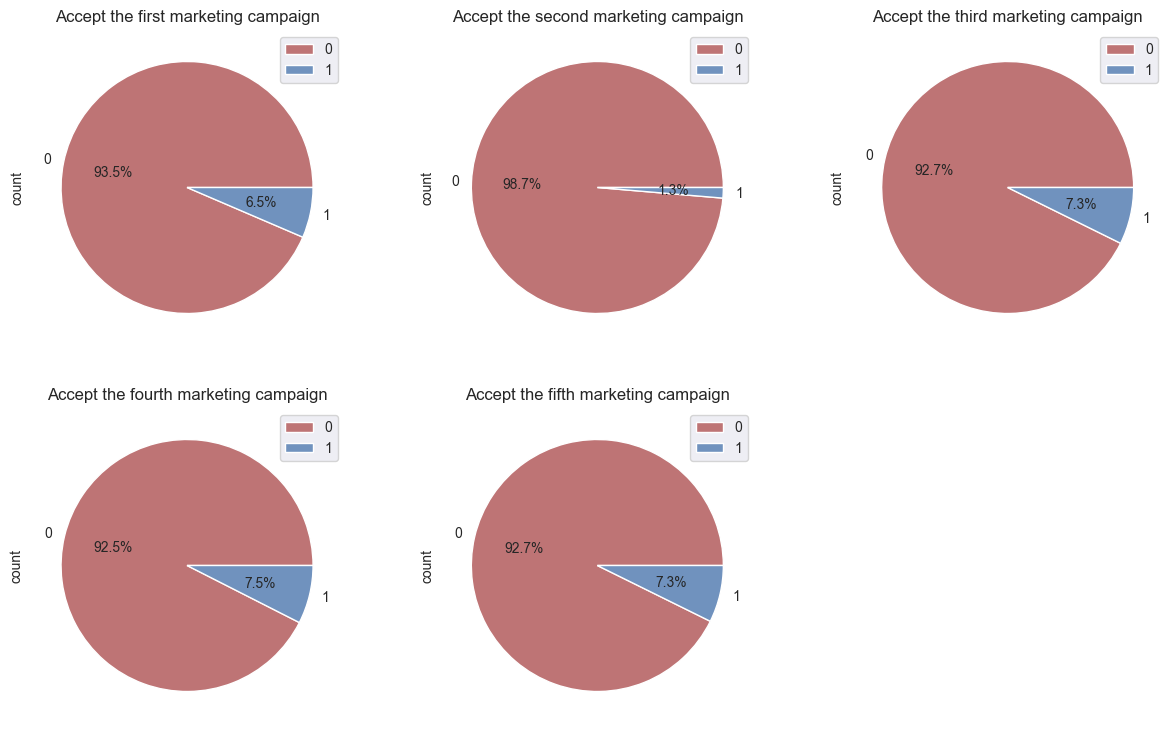

In [29]:
mp1 = df['AcceptedCmp1'].value_counts()
mp2 = df['AcceptedCmp2'].value_counts()
mp3 = df['AcceptedCmp3'].value_counts()
mp4 = df['AcceptedCmp4'].value_counts()
mp5 = df['AcceptedCmp5'].value_counts()

plt.figure(figsize=(15,9))
max_color = '#BE7475'
min_color = '#7092BE'

sp.multe_pie(2,3,1, mp1, True, 'Accept the first marketing campaign', max_color, min_color)
sp.multe_pie(2,3,2, mp2, True, 'Accept the second marketing campaign', max_color, min_color)
sp.multe_pie(2,3,3, mp3, True, 'Accept the third marketing campaign', max_color, min_color)
sp.multe_pie(2,3,4, mp4, True, 'Accept the fourth marketing campaign', max_color, min_color)
sp.multe_pie(2,3,5, mp5, True, 'Accept the fifth marketing campaign', max_color, min_color)

## *11. Complain*

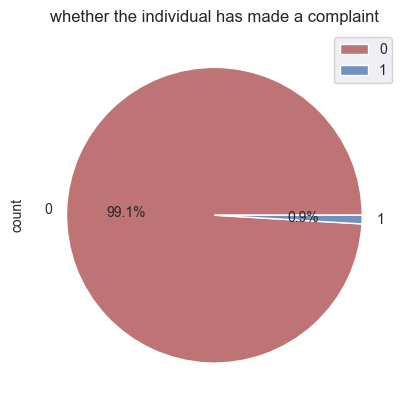

In [30]:
x = df['Complain'].value_counts()

x.plot(kind='pie', autopct='%1.1f%%', legend=True, colors=['#BE7475','#7092BE'], title='whether the individual has made a complaint')
plt.show()

## *12. Response*

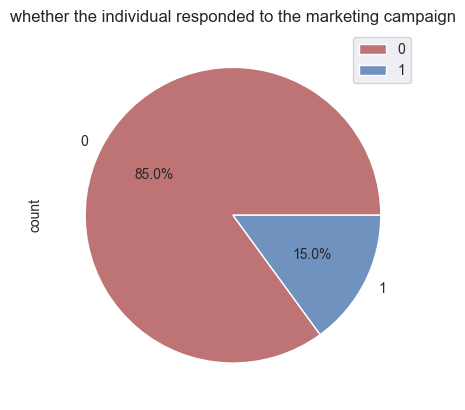

In [31]:
x = df['Response'].value_counts()

x.plot(kind='pie', autopct='%1.1f%%', legend=True, colors=['#BE7475','#7092BE'], title='whether the individual responded to the marketing campaign')
plt.show()

---

# **Preprocessing:**

### ***- encoding***

In [32]:
encoder = LabelEncoder()

df['Education'] = encoder.fit_transform(df['Education'])
df['Marital_Status'] = encoder.fit_transform(df['Marital_Status'])

---

# **ML model**

In [33]:
df['Purchases'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [34]:
df.head(10)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_day,Dt_month,Dt_year,Recency,...,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Complain,Z_CostContact,Z_Revenue,Response,Purchases
0,1957,2,4,58138.0,0,0,4,9,2012,58,...,0,0,0,0,0,0,3,11,1,1617
1,1954,2,4,46344.0,1,1,8,3,2014,38,...,0,0,0,0,0,0,3,11,0,27
2,1965,2,5,71613.0,0,0,21,8,2013,26,...,0,0,0,0,0,0,3,11,0,776
3,1984,2,5,26646.0,1,0,10,2,2014,26,...,0,0,0,0,0,0,3,11,0,53
4,1981,4,3,58293.0,1,0,19,1,2014,94,...,0,0,0,0,0,0,3,11,0,422
5,1967,3,5,62513.0,0,1,9,9,2013,16,...,0,0,0,0,0,0,3,11,0,716
6,1971,2,2,55635.0,0,1,13,11,2012,34,...,0,0,0,0,0,0,3,11,0,590
7,1985,4,3,33454.0,1,0,8,5,2013,32,...,0,0,0,0,0,0,3,11,0,169
8,1974,4,5,30351.0,1,0,6,6,2013,19,...,0,0,0,0,0,0,3,11,1,46
9,1950,4,5,5648.0,1,1,13,3,2014,68,...,0,0,1,0,0,0,3,11,0,49


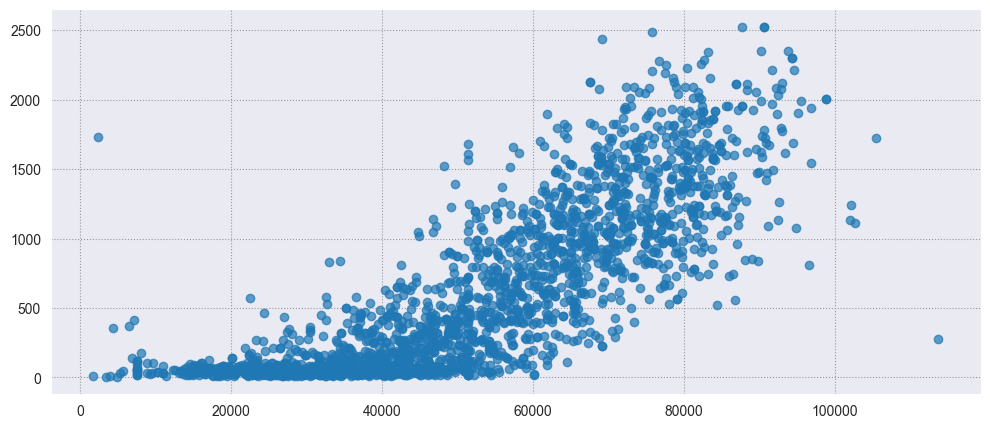

In [35]:
plt.figure(figsize=(12, 5))

plt.scatter(df['Income'], df['Purchases'], alpha=0.7)
plt.show()

### ***1. k-means++***

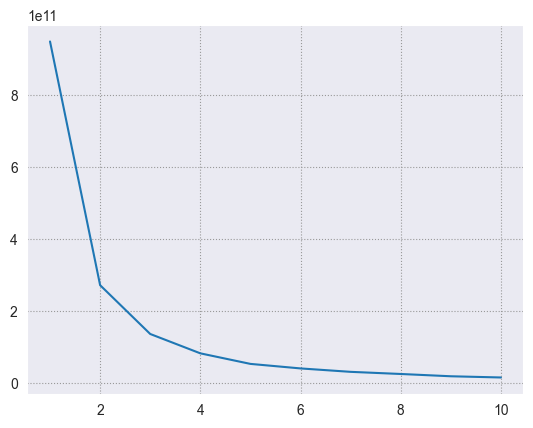

In [36]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, max_iter=3000, random_state=42)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.show()

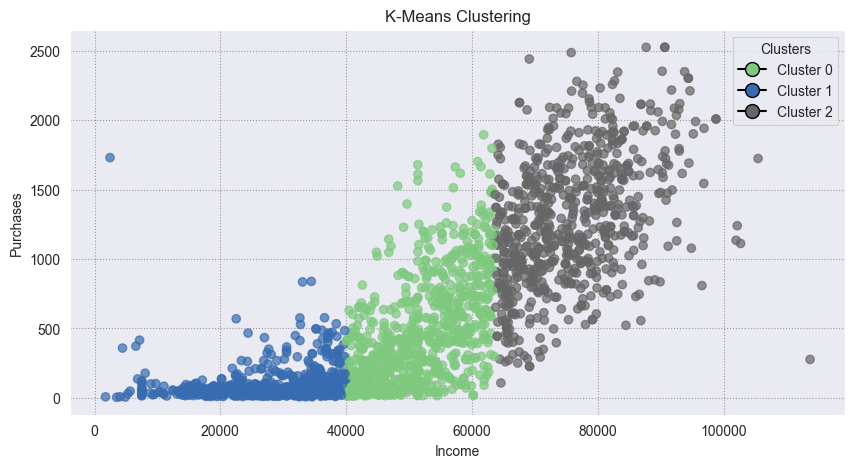

In [37]:
# K-Means clustering
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans_labels = kmeans.fit_predict(df)

# Visualize K-Means clustering
plt.figure(figsize=(10, 5))

# Create a scatter plot
scatter = plt.scatter(df['Income'], df['Purchases'], c=kmeans_labels, cmap='Accent', alpha=0.7)

# Create custom legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='black', label=f'Cluster {i}', 
                           markerfacecolor=scatter.cmap(scatter.norm(i)), markersize=10) 
                   for i in range(3)]
plt.legend(handles=legend_elements, title='Clusters')

plt.title('K-Means Clustering')
plt.xlabel('Income')
plt.ylabel('Purchases')

plt.show()

### ***2. DBSCAN***

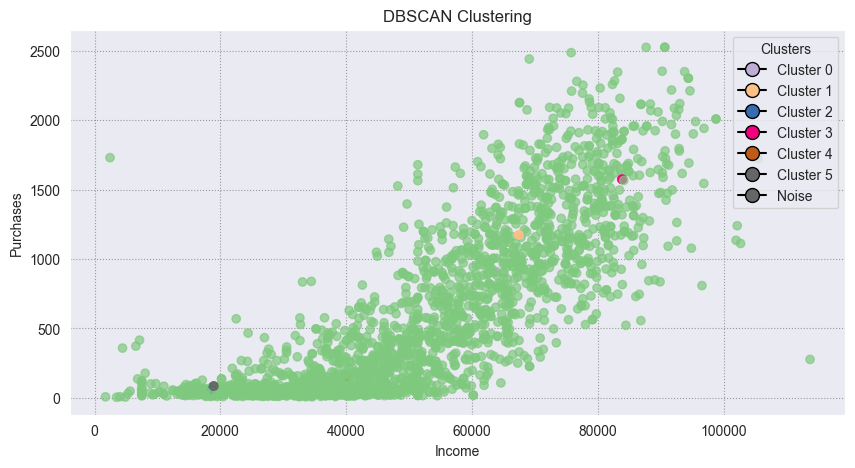

In [38]:
# DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=3)
dbscan_labels = dbscan.fit_predict(df)

# Visualize DBSCAN clustering
plt.figure(figsize=(10, 5))

# Create a scatter plot
scatter = plt.scatter(df['Income'], df['Purchases'], c=dbscan_labels, cmap='Accent', alpha=0.7)

# Create a legend
unique_labels = set(dbscan_labels)
legend_labels = [f'Cluster {label}' if label != -1 else 'Noise' for label in unique_labels]

# Add legend
handles = [plt.Line2D([0], [0], marker='o', color='black', label=legend_labels[i], 
                       markerfacecolor=scatter.cmap(scatter.norm(i)), markersize=10) 
           for i in range(len(legend_labels))]
plt.legend(handles=handles, title="Clusters")

plt.title('DBSCAN Clustering')
plt.xlabel('Income')
plt.ylabel('Purchases')

plt.show()

### ***3. AgglomerativeClustering***

In [39]:
# Choose the number of clusters
num_clusters = 2

# Perform hierarchical clustering
agg_clustering = AgglomerativeClustering(n_clusters=num_clusters)
cluster_labels = agg_clustering.fit_predict(df)

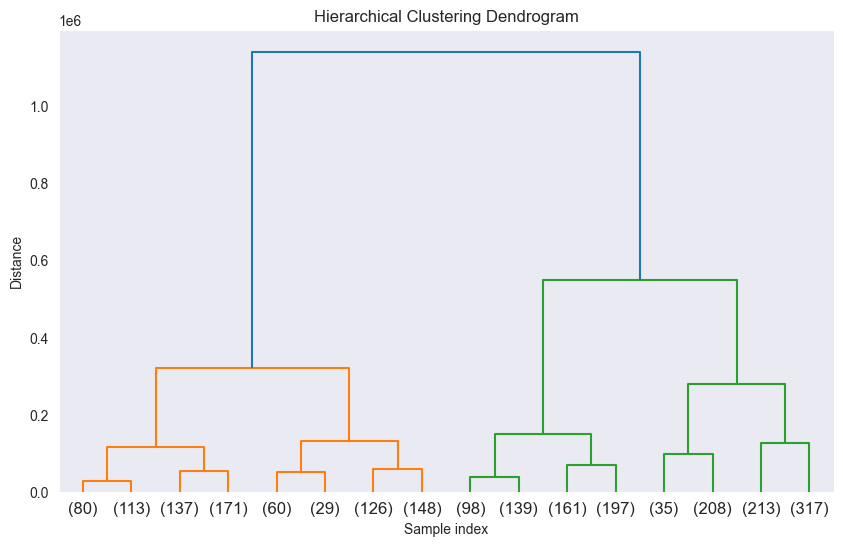

In [40]:
# Perform Agglomerative Hierarchical Clustering
model = AgglomerativeClustering(n_clusters=None, distance_threshold=0, linkage='ward')
model.fit(df)
labels = model.labels_

# Compute linkage matrix
linkage_matrix = linkage(df, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=3)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.grid(False)
plt.show()